# Eksplorasi: CNN + Channel/Spatial Attention (S2-attn)

**Input:** Citra X-ray dada (224×224 piksel, 3 channel), sama seperti S2.

**Arsitektur:** DenseNet-121 (bobot CheXNet) + `ChannelSpatialAttention` (A3Net-style channel-wise + element-wise/spatial attention) disisipkan antara feature extractor dan Global Average Pooling.

**Motivasi:** hasil DeLong test S3 (fusi) vs S2 (citra) tidak signifikan (p=0,65) — literatur menunjukkan attention module memberi kenaikan AUC terbesar justru pada backbone DenseNet/ResNet (A3Net: DenseNet-121 + triple attention, AUC 0,826 di NIH ChestX-ray14 multi-label; Wang et al. 2020, *Medical Image Analysis*), sementara EfficientNet menunjukkan "diminishing returns" untuk attention (Imran et al. 2026, *Scientific Reports*). Eksperimen ini menguji apakah menambah attention ke DenseNet-121 yang sudah ada — bukan mengganti backbone — bisa menaikkan AUC S2 dari baseline 0,7442.

**Catatan:** ini eksperimen eksploratif (bukan skenario resmi proposal). Checkpoint dan hasil disimpan terpisah (`model_s2-attn_best.pt`, `results_s2attn.csv`) — tidak menimpa S2 baseline.

## 1. Setup & Load Dataset

In [1]:
import sys
sys.path.insert(0, r"D:\TA\nih-multimodal")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.amp import autocast, GradScaler
from tqdm.auto import tqdm
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    confusion_matrix, roc_curve, accuracy_score
)

from configs.config import cfg
from src.models.architectures import ImageCNNAttn
from src.data.dataset import create_dataloaders
from src.evaluation.stats import delong_test, bootstrap_auc_ci

torch.manual_seed(cfg.train.seed)
np.random.seed(cfg.train.seed)

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = cfg.paths.figures_dir
CKPT_DIR = cfg.paths.checkpoint_dir
TABLES_DIR = cfg.paths.project_root / "results" / "tables"
for d in [SAVE_DIR, CKPT_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Device  : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"AMP     : {cfg.train.use_amp}")
print(f"Grad Accum Steps: {cfg.train.gradient_accumulation_steps} "
      f"(effective batch = {cfg.train.batch_size * cfg.train.gradient_accumulation_steps})")

Device  : cuda
GPU     : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM    : 6.4 GB
AMP     : True
Grad Accum Steps: 2 (effective batch = 32)


In [2]:
# create_dataloaders() menangani: image index, metadata, patient-level split, transforms, scaler
train_loader, val_loader, test_loader, scaler, pos_weights = create_dataloaders(
    batch_size=cfg.train.batch_size
)

print("\nDataloader siap.")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

# Hitung pos_weight binary dari train set
y_train_all = []
for batch in train_loader:
    y_train_all.append(batch["label_binary"].numpy())
y_train_all = np.concatenate(y_train_all)
pos_ratio = y_train_all.mean()
pw_binary = torch.tensor([(1 - pos_ratio) / pos_ratio], dtype=torch.float32).to(DEVICE)
print(f"\nPos ratio (train binary) : {pos_ratio:.3f}")
print(f"pos_weight               : {pw_binary.item():.3f}")

[Data] Indexed 112120 images across 12 directories


[Data] Loaded metadata: 112120 samples, 30805 patients
[Data] Split — Train: 77994 | Val: 8530 | Test: 25596

Dataloader siap.
Train batches : 4874
Val batches   : 267
Test batches  : 800



Pos ratio (train binary) : 0.417
pos_weight               : 1.400


## 2. Model, Optimizer, Scheduler

In [3]:
# S2-attn: DenseNet-121 + channel/spatial attention, binary output
model = ImageCNNAttn(num_classes=1).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pw_binary)
scaler_amp = GradScaler('cuda', enabled=cfg.train.use_amp)

# Differential learning rate: backbone lebih kecil, attention+head sama dengan fusion LR
optimizer = torch.optim.AdamW([
    {"params": model.branch.features.parameters(),   "lr": cfg.train.lr_backbone},
    {"params": model.branch.attention.parameters(),  "lr": cfg.train.lr_fusion},
    {"params": model.branch.projection.parameters(), "lr": cfg.train.lr_fusion},
    {"params": model.classifier.parameters(),        "lr": cfg.train.lr_fusion},
], weight_decay=cfg.train.weight_decay)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=cfg.train.scheduler_patience,
    factor=cfg.train.scheduler_factor
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
attn_params      = sum(p.numel() for p in model.branch.attention.parameters())
print(f"Model          : DenseNet-121 + ChannelSpatialAttention (S2-attn Binary)")
print(f"Total params   : {total_params:,}")
print(f"Trainable      : {trainable_params:,}")
print(f"Attention only : {attn_params:,}")
print(f"LR backbone    : {cfg.train.lr_backbone}")
print(f"LR head/attn   : {cfg.train.lr_fusion}")

[ImageBranch] CheXNet weights loaded — all keys matched perfectly


Model          : DenseNet-121 + ChannelSpatialAttention (S2-attn Binary)
Total params   : 7,612,452
Trainable      : 2,714,500
Attention only : 132,259
LR backbone    : 0.0001
LR head/attn   : 0.0005


## 3. Training Loop (dengan progress bar tqdm)

In [4]:
ACCUM_STEPS = cfg.train.gradient_accumulation_steps


def train_epoch(model, loader, criterion, optimizer, scaler_amp, device, accum_steps, epoch_num):
    model.train()
    total_loss, n = 0.0, 0
    all_probs, all_labels = [], []
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(loader, desc=f"Epoch {epoch_num} [train]", leave=False)
    for step, batch in enumerate(pbar):
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label_binary"].to(device, non_blocking=True)

        with autocast('cuda', enabled=cfg.train.use_amp):
            logits = model(image=images).squeeze(1)
            loss   = criterion(logits, labels) / accum_steps

        scaler_amp.scale(loss).backward()

        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
            scaler_amp.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler_amp.step(optimizer)
            scaler_amp.update()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * accum_steps * len(labels)
        n += len(labels)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.cpu().numpy())

        if step % 20 == 0:
            pbar.set_postfix(loss=f"{total_loss/max(n,1):.4f}")

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    return total_loss / n, roc_auc_score(all_labels, all_probs)


@torch.no_grad()
def evaluate(model, loader, criterion, device, desc="eval"):
    model.eval()
    total_loss, n = 0.0, 0
    all_probs, all_labels = [], []

    for batch in tqdm(loader, desc=desc, leave=False):
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label_binary"].to(device, non_blocking=True)

        with autocast('cuda', enabled=cfg.train.use_amp):
            logits = model(image=images).squeeze(1)
            loss   = criterion(logits, labels)

        total_loss += loss.item() * len(labels)
        n += len(labels)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    return total_loss / n, roc_auc_score(all_labels, all_probs), all_probs, all_labels


# ── Main training loop ──
CKPT_PATH = CKPT_DIR / "model_s2-attn_best.pt"
history   = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": []}
best_val_auc     = 0.0
patience_counter = 0
t0 = time.time()

print(f"{'Epoch':>5} {'Train Loss':>12} {'Train AUC':>10} {'Val Loss':>10} {'Val AUC':>9} {'LR (bb)':>10} {'Time':>7}")
print("-" * 72)

for epoch in range(1, cfg.train.num_epochs + 1):
    ep_start = time.time()

    train_loss, train_auc = train_epoch(
        model, train_loader, criterion, optimizer, scaler_amp, DEVICE, ACCUM_STEPS, epoch
    )
    val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion, DEVICE, desc=f"Epoch {epoch} [val]")

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_auc"].append(train_auc)
    history["val_auc"].append(val_auc)

    scheduler.step(val_auc)
    current_lr = optimizer.param_groups[0]["lr"]
    ep_time    = time.time() - ep_start

    flag = ""
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), CKPT_PATH)
        patience_counter = 0
        flag = " \u2713"
    else:
        patience_counter += 1

    print(f"{epoch:>5} {train_loss:>12.4f} {train_auc:>10.4f} "
          f"{val_loss:>10.4f} {val_auc:>9.4f} {current_lr:>10.2e} "
          f"{ep_time:>6.1f}s{flag}")

    if patience_counter >= cfg.train.early_stop_patience:
        print(f"\nEarly stopping di epoch {epoch} (patience={cfg.train.early_stop_patience})")
        break

total_time = time.time() - t0
print(f"\nTraining selesai dalam {total_time/60:.1f} menit")
print(f"Best Val AUC : {best_val_auc:.4f}")
print(f"Model tersimpan: {CKPT_PATH}")

Epoch   Train Loss  Train AUC   Val Loss   Val AUC    LR (bb)    Time
------------------------------------------------------------------------


Epoch 1 [train]:   0%|          | 0/4874 [00:00<?, ?it/s]

Epoch 1 [val]:   0%|          | 0/267 [00:21<?, ?it/s]

    1       0.6832     0.7624     0.6647    0.7799   1.00e-04  784.3s ✓


Epoch 2 [train]:   0%|          | 0/4874 [00:00<?, ?it/s]

...

Epoch 10 [val]:   0%|          | 0/267 [00:00<?, ?it/s]

   10       0.6590     0.7814     0.6566    0.7882   5.00e-05  757.7s


Epoch 11 [train]:   0%|          | 0/4874 [00:00<?, ?it/s]

Epoch 11 [val]:   0%|          | 0/267 [00:00<?, ?it/s]

   11       0.6591     0.7812     0.6573    0.7867   5.00e-05  751.7s

Early stopping di epoch 11 (patience=7)

Training selesai dalam 138.3 menit
Best Val AUC : 0.7904
Model tersimpan: D:\TA\nih-multimodal\results\checkpoints\model_s2-attn_best.pt


## 4. Training Curves

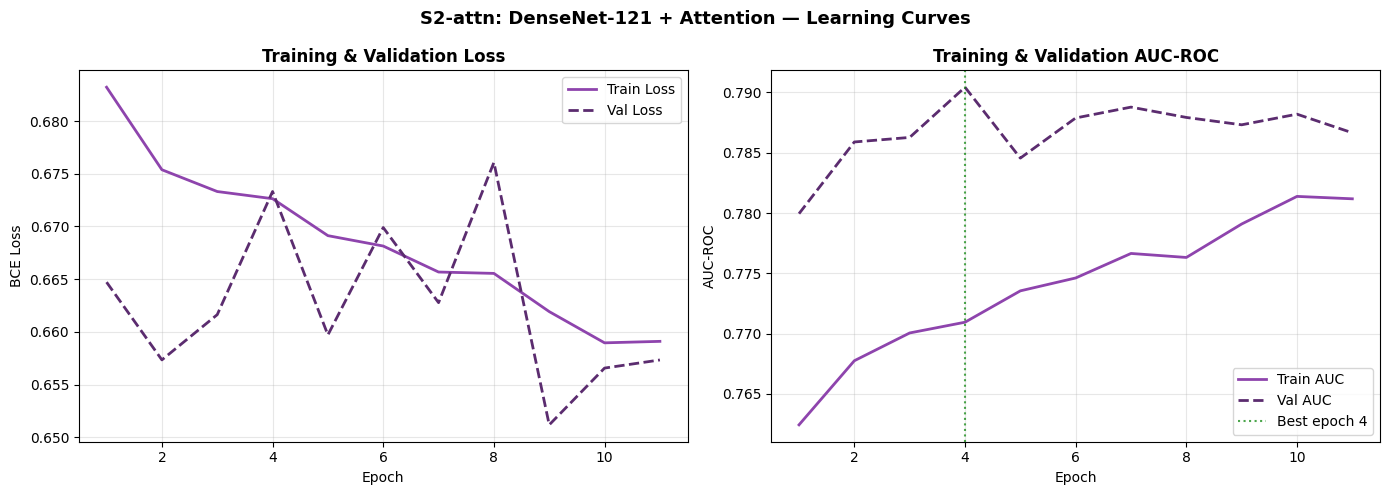

Disimpan → results/figures/s2attn_training_curves.png


In [5]:
epochs_ran = range(1, len(history["train_loss"]) + 1)
best_ep    = np.argmax(history["val_auc"]) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, history["train_loss"], label="Train Loss", color="#8e44ad", linewidth=2)
axes[0].plot(epochs_ran, history["val_loss"],   label="Val Loss",   color="#5b2c6f", linewidth=2, linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Training & Validation Loss", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history["train_auc"], label="Train AUC", color="#8e44ad", linewidth=2)
axes[1].plot(epochs_ran, history["val_auc"],   label="Val AUC",   color="#5b2c6f", linewidth=2, linestyle="--")
axes[1].axvline(best_ep, color="green", linestyle=":", alpha=0.7, label=f"Best epoch {best_ep}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC-ROC")
axes[1].set_title("Training & Validation AUC-ROC", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("S2-attn: DenseNet-121 + Attention — Learning Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "s2attn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan \u2192 results/figures/s2attn_training_curves.png")

## 5. Evaluasi pada Test Set

In [6]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
_, test_auc, test_probs, test_labels = evaluate(model, test_loader, criterion, DEVICE, desc="test")

test_preds = (test_probs >= 0.5).astype(int)

acc      = accuracy_score(test_labels, test_preds)
f1       = f1_score(test_labels, test_preds, average="binary")
f1_macro = f1_score(test_labels, test_preds, average="macro")
auc      = roc_auc_score(test_labels, test_probs)

print("=" * 55)
print("HASIL EVALUASI S2-attn: DenseNet-121 + Attention")
print("=" * 55)
print(f"Accuracy       : {acc:.4f}")
print(f"F1-Score (bin) : {f1:.4f}")
print(f"F1-Score (mac) : {f1_macro:.4f}")
print(f"AUC-ROC        : {auc:.4f}")
print()
print(classification_report(test_labels, test_preds, target_names=["Normal", "Abnormal"]))

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9796\3927907385.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVIC

test:   0%|          | 0/800 [00:37<?, ?it/s]

HASIL EVALUASI S2-attn: DenseNet-121 + Attention
Accuracy       : 0.7314
F1-Score (bin) : 0.8022
F1-Score (mac) : 0.6920
AUC-ROC        : 0.7471

              precision    recall  f1-score   support

      Normal       0.73      0.49      0.58      9861
    Abnormal       0.73      0.89      0.80     15735

    accuracy                           0.73     25596
   macro avg       0.73      0.69      0.69     25596
weighted avg       0.73      0.73      0.72     25596



## 6. Bandingkan dengan S2 Baseline (DeLong Test)

In [7]:
s2_baseline_path = TABLES_DIR / "predictions_s2.csv"

if s2_baseline_path.exists():
    s2_df = pd.read_csv(s2_baseline_path)
    s2_probs  = s2_df["prob_s2"].to_numpy()
    s2_labels = s2_df["true_label"].to_numpy()

    if len(s2_labels) == len(test_labels) and (s2_labels == test_labels.astype(int)).all():
        ci_base = bootstrap_auc_ci(s2_probs, s2_labels)
        ci_attn = bootstrap_auc_ci(test_probs, test_labels)

        print("=" * 60)
        print("S2-attn (DenseNet+Attention) vs S2 baseline (DenseNet biasa)")
        print("=" * 60)
        print(f"S2 baseline : AUC={ci_base['auc']:.4f}  95% CI=[{ci_base['ci_low']:.4f}, {ci_base['ci_high']:.4f}]")
        print(f"S2-attn     : AUC={ci_attn['auc']:.4f}  95% CI=[{ci_attn['ci_low']:.4f}, {ci_attn['ci_high']:.4f}]")

        d = delong_test(test_probs, s2_probs, test_labels)
        sig = "SIGNIFICANT (p<0.05)" if d["p_value"] < 0.05 else "not significant (p>=0.05)"
        print(f"\nDeLong S2-attn vs S2: dAUC={d['delta_auc']:+.4f}  z={d['z']:.3f}  p={d['p_value']:.4f}  -> {sig}")
    else:
        print("[Warn] Test set S2 baseline tidak sejajar dengan S2-attn \u2014 lewati perbandingan DeLong.")
else:
    print(f"[Warn] Tidak ada baseline predictions di {s2_baseline_path} \u2014 lewati perbandingan.")

S2-attn (DenseNet+Attention) vs S2 baseline (DenseNet biasa)
S2 baseline : AUC=0.7442  95% CI=[0.7379, 0.7506]
S2-attn     : AUC=0.7471  95% CI=[0.7410, 0.7532]

DeLong S2-attn vs S2: dAUC=+0.0029  z=3.143  p=0.0017  -> SIGNIFICANT (p<0.05)


## 7. Confusion Matrix & ROC Curve

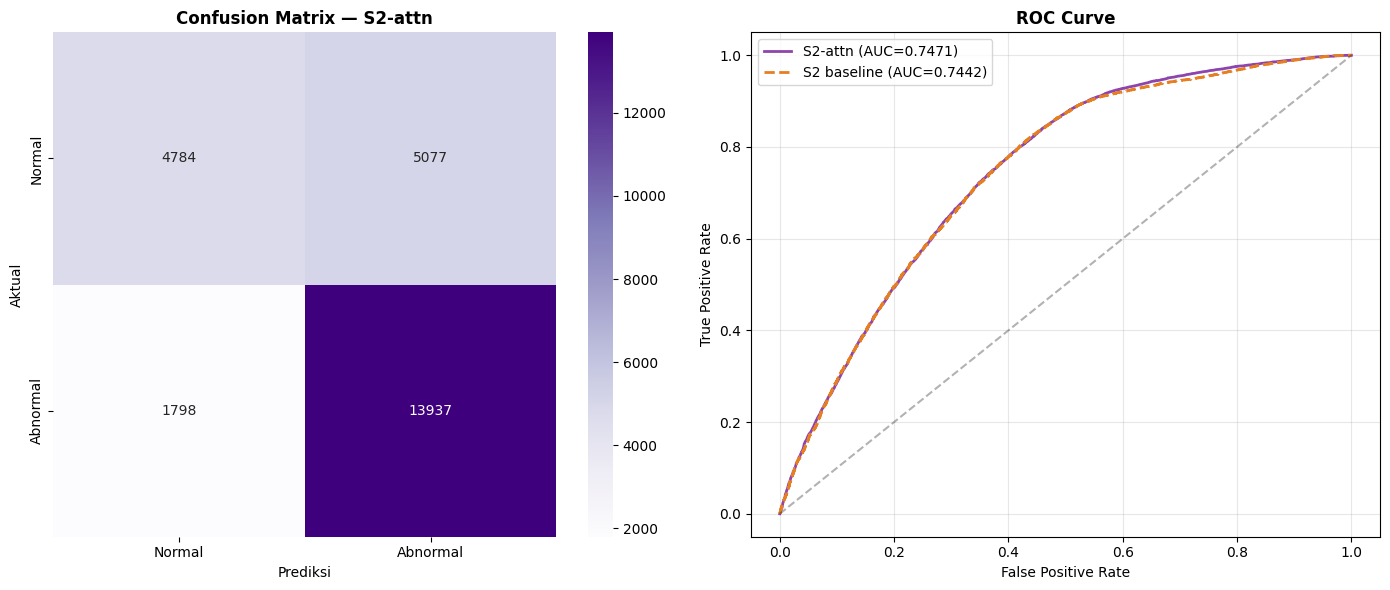

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", ax=axes[0],
            xticklabels=["Normal", "Abnormal"], yticklabels=["Normal", "Abnormal"])
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Aktual")
axes[0].set_title("Confusion Matrix — S2-attn", fontweight="bold")

fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, color="#8e44ad", linewidth=2, label=f"S2-attn (AUC={auc:.4f})")
if s2_baseline_path.exists() and len(s2_labels) == len(test_labels):
    fpr_b, tpr_b, _ = roc_curve(s2_labels, s2_probs)
    axes[1].plot(fpr_b, tpr_b, color="#e67e22", linewidth=2, linestyle="--", label=f"S2 baseline (AUC={ci_base['auc']:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / "s2attn_confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Simpan Hasil

In [9]:
results_s2attn = {
    "Skenario"    : "S2-attn",
    "Model"       : "DenseNet-121 + ChannelSpatialAttention",
    "Input"       : "Gambar X-ray (224\u00d7224)",
    "Accuracy"    : round(acc, 4),
    "F1 (Binary)" : round(f1, 4),
    "F1 (Macro)"  : round(f1_macro, 4),
    "AUC-ROC"     : round(auc, 4),
    "Best Epoch"  : best_ep,
    "Best Val AUC": round(best_val_auc, 4),
}

pd.DataFrame([results_s2attn]).to_csv(TABLES_DIR / "results_s2attn.csv", index=False)

pd.DataFrame({
    "true_label": test_labels.astype(int),
    "prob_s2attn": test_probs,
    "pred_s2attn": test_preds,
}).to_csv(TABLES_DIR / "predictions_s2attn.csv", index=False)

print("Disimpan:")
print(f"  {TABLES_DIR / 'results_s2attn.csv'}")
print(f"  {TABLES_DIR / 'predictions_s2attn.csv'}")
print(f"  Model checkpoint: {CKPT_PATH}")
print()
print("CATATAN: hasil ini eksploratif (bukan skenario resmi proposal).")
print("Bandingkan AUC S2-attn di atas dengan S2 baseline (0.7442) dan cek")
print("signifikansi DeLong di cell sebelumnya sebelum memutuskan apakah")
print("attention worth dilaporkan di naskah.")

Disimpan:
  D:\TA\nih-multimodal\results\tables\results_s2attn.csv
  D:\TA\nih-multimodal\results\tables\predictions_s2attn.csv
  Model checkpoint: D:\TA\nih-multimodal\results\checkpoints\model_s2-attn_best.pt

CATATAN: hasil ini eksploratif (bukan skenario resmi proposal).
Bandingkan AUC S2-attn di atas dengan S2 baseline (0.7442) dan cek
signifikansi DeLong di cell sebelumnya sebelum memutuskan apakah
attention worth dilaporkan di naskah.
